# **A. Introduction**

## **1. Problem Statement**

Klasifikasi penyakit daun anggur berdasarkan citra menggunakan ekstraksi fitur
HSV (warna) dan GLCM (tekstur) dengan algoritma SVM

## **2. Objective**

Membangun model klasifikasi untuk mengidentifikasi penyakit pada daun anggur:
- Black Measles
- Black Rot  
- Healthy
- Isariopsis Leaf Spot

# **C. Persiapan & Import Library**

## **1. Install & Import Library**



In [2]:
!pip install opencv-python scikit-learn pandas numpy matplotlib seaborn tqdm scikit-image joblib -q

import numpy as np
import pandas as pd
import os, glob
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import *
import joblib

## **2. Mount Google Drive (Google Colab)**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **D. Data Preparation**

## **1. Load Dataset dari Google Drive**

In [4]:
path_data = '/content/drive/MyDrive/Computer vision/UTS/Data'

if not os.path.exists(path_data):
    raise Exception("❌ Path salah!")

print("✅ Path valid")

✅ Path valid


## **2. Labeling Data (Function)**

In [5]:
def get_label(path):
    path = path.lower()
    if 'black measles' in path:
        return 'black_measles'
    elif 'black rot' in path:
        return 'black_rot'
    elif 'healthy' in path:
        return 'healthy'
    elif 'isariopsis' in path:
        return 'isariopsis_leaf_spot'
    return None

# **E. Feature Extraction (Computer Vision Core )**

In [11]:
# EKSTRAKSI FITUR HSV + GLCM
def extract_features(path):
    img = cv2.imread(path)
    if img is None:
        return None

    # Resize
    img = cv2.resize(img, (128, 128))

    # HSV FEATURES (WARNA)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    hsv_feat = {
        'H_mean': np.mean(h),
        'S_mean': np.mean(s),
        'V_mean': np.mean(v),
        'H_std': np.std(h),
        'S_std': np.std(s),
        'V_std': np.std(v),
    }

    # GLCM FEATURES (TEKSTUR)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Rescale ke 0-31 (32 level) agar GLCM cepat
    gray_rescaled = (gray / 8).astype(np.uint8)

    glcm = graycomatrix(
        gray_rescaled,
        distances=[1],
        angles=[0],
        levels=32,  # lebih kecil = lebih cepat
        symmetric=True,
        normed=True
    )

    glcm_feat = {
        'contrast': graycoprops(glcm, 'contrast')[0, 0],
        'dissimilarity': graycoprops(glcm, 'dissimilarity')[0, 0],
        'homogeneity': graycoprops(glcm, 'homogeneity')[0, 0],
        'energy': graycoprops(glcm, 'energy')[0, 0],
        'correlation': graycoprops(glcm, 'correlation')[0, 0],
    }

    return {**hsv_feat, **glcm_feat}

# **F. Load Image Dataset (Loop Semua)**

In [13]:
import cv2
paths = []
for ext in ['*.jpg','*.png','*.jpeg','*.JPG']:
    paths += glob.glob(os.path.join(path_data,'**',ext), recursive=True)

print(f"Total gambar: {len(paths)}")

data = []

for p in tqdm(paths):
    label = get_label(p)
    if label is None:
        continue

    feat = extract_features(p)
    if feat:
        feat['label'] = label
        data.append(feat)

df = pd.DataFrame(data)

print("✅ Dataset:", df.shape)
df.head()

Total gambar: 9027


100%|██████████| 9027/9027 [46:19<00:00,  3.25it/s]

✅ Dataset: (9027, 12)


,H_mean,S_mean,V_mean,H_std,S_std,V_std,contrast,dissimilarity,homogeneity,energy,correlation,label
0,69.668945,59.319336,114.678406,59.413152,51.485804,44.004758,2.621924,1.080955,0.585301,0.117714,0.961092,black_rot
1,53.103027,61.533386,119.555969,47.913322,50.843369,43.400229,3.225394,1.197589,0.558471,0.105110,0.951400,black_rot
2,77.798218,59.033875,117.774414,62.669737,55.867644,37.629868,3.256336,1.173782,0.574465,0.127811,0.937408,black_rot
3,101.222839,84.635986,120.281006,60.587636,58.644212,34.383683,3.041892,1.173290,0.567470,0.118729,0.925237,black_rot
4,76.190613,63.019287,127.210205,64.202958,54.626416,32.881958,2.195989,1.006767,0.597394,0.134936,0.947372,black_rot


# **G. Exploratory Data Analysis (EDA)**

## **1. Statistik Data**

In [14]:
print("\n📊 INFO DATASET")
print(df.info())

print("\n📊 STATISTIK")
print(df.describe())


📊 INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9027 entries, 0 to 9026
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   H_mean         9027 non-null   float64
 1   S_mean         9027 non-null   float64
 2   V_mean         9027 non-null   float64
 3   H_std          9027 non-null   float64
 4   S_std          9027 non-null   float64
 5   V_std          9027 non-null   float64
 6   contrast       9027 non-null   float64
 7   dissimilarity  9027 non-null   float64
 8   homogeneity    9027 non-null   float64
 9   energy         9027 non-null   float64
 10  correlation    9027 non-null   float64
 11  label          9027 non-null   object 
dtypes: float64(11), object(1)
memory usage: 846.4+ KB
None

📊 STATISTIK
            H_mean       S_mean       V_mean        H_std        S_std  \
count  9027.000000  9027.000000  9027.000000  9027.000000  9027.000000   
mean     57.717689    75.229006   134.53

# **H. Data Visualization**

### **1. Bar Chart (Distribusi Kelas)**


🏷️ DISTRIBUSI KELAS
label
black_measles           2400
black_rot               2360
isariopsis_leaf_spot    2152
healthy                 2115
Name: count, dtype: int64


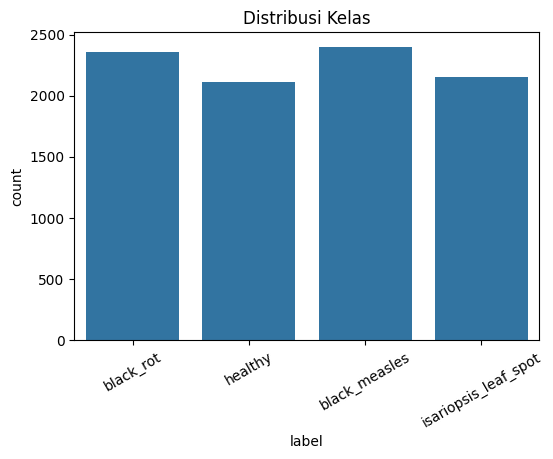

In [35]:
print("\n🏷️ DISTRIBUSI KELAS")
print(df['label'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Distribusi Kelas")
plt.xticks(rotation=30)
plt.show()

## **2. Boxplot (Feature Distribution)**

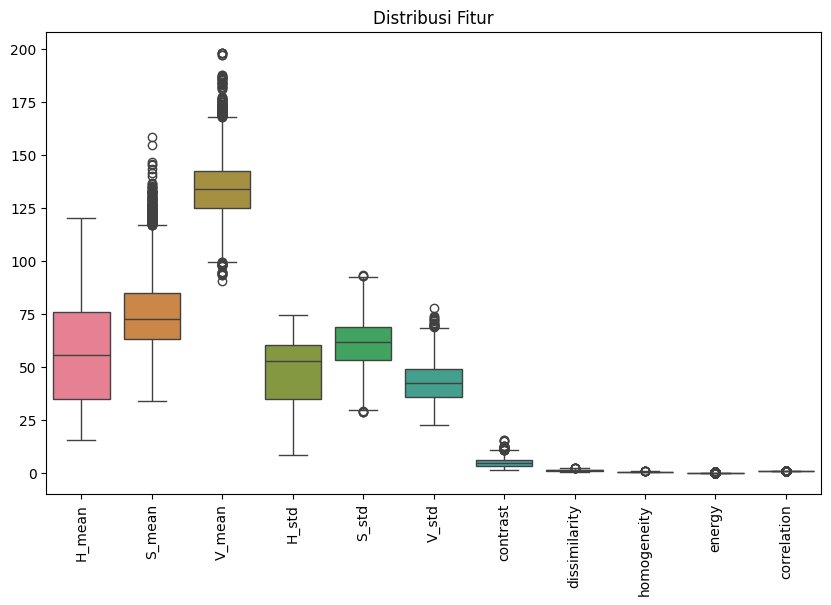

In [16]:
# VISUALISASI FITUR

plt.figure(figsize=(10,6))
sns.boxplot(data=df.drop('label', axis=1))
plt.xticks(rotation=90)
plt.title("Distribusi Fitur")
plt.show()

## **3. Scatter Plot (Texture Analysis)**

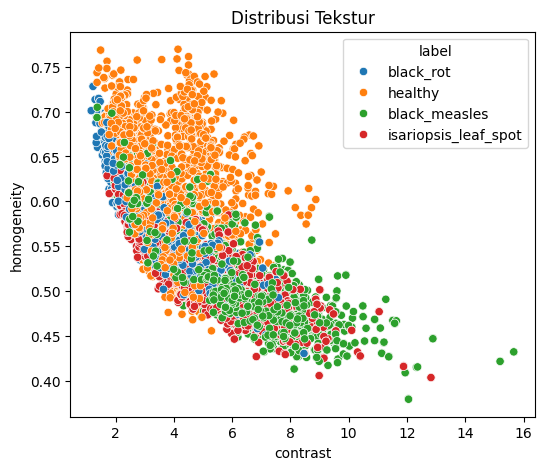

In [17]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='contrast', y='homogeneity', hue='label', data=df)
plt.title("Distribusi Tekstur")
plt.show()

## **4. Correlation Matrix (Heatmap)**

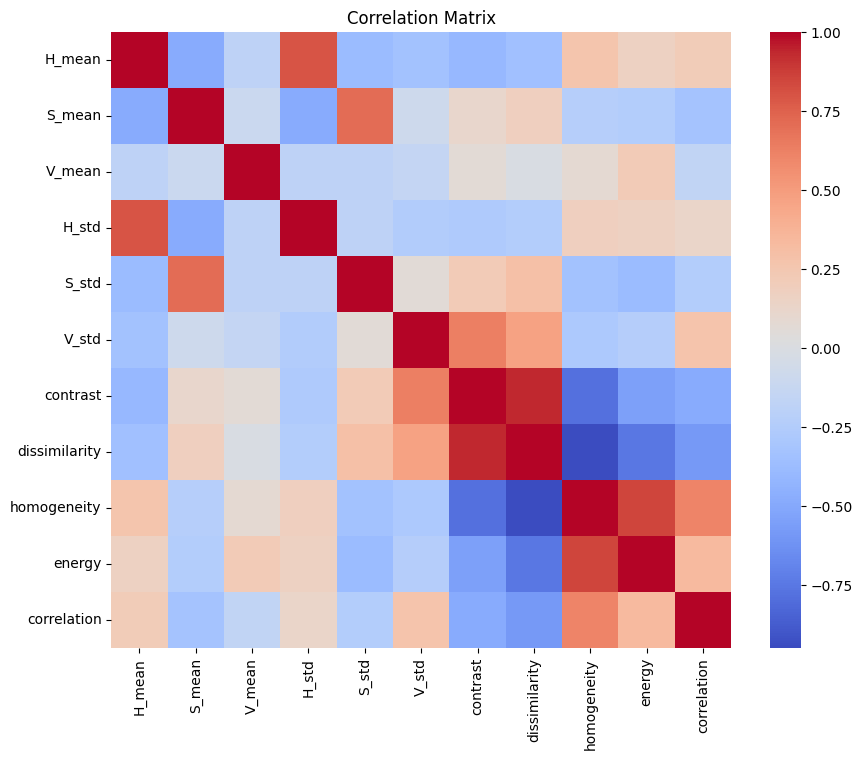

In [18]:
# CORRELATION MATRIX

plt.figure(figsize=(10,8))
corr = df.drop('label', axis=1).corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# **I. Data Preprocessing**

In [19]:
# PREPROCESSING
print("="*60)
print("🔄 PREPROCESSING DATA")
print("="*60)

X = df.drop('label', axis=1)
y = df['label']

print(f"📊 Total data: {len(X)}")
print(f"📊 Distribusi kelas:")
print(y.value_counts())

# Encode label
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    stratify=y_enc,  #  menjaga proporsi kelas
    random_state=42
)

print(f"\n📂 Split data:")
print(f"   Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Normalisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Normalisasi selesai")

🔄 PREPROCESSING DATA
📊 Total data: 9027
📊 Distribusi kelas:
label
black_measles           2400
black_rot               2360
isariopsis_leaf_spot    2152
healthy                 2115
Name: count, dtype: int64

📂 Split data:
   Train: 7221 (80.0%)
   Test : 1806 (20.0%)
✅ Normalisasi selesai


# **J. Machine Learning Model (SVM)**

In [22]:
# TRAINING SVM

print("="*60)
print("TRAINING SVM DENGAN GRID SEARCH")
print("="*60)

param_grid = {
    'C': [1, 10, 50, 100],
    'gamma': [0.01, 0.1, 1, 'scale'],
    'kernel': ['rbf']
}

print(f"Parameter yang diuji: {len(param_grid['C']) * len(param_grid['gamma'])} kombinasi")

svm = SVC(random_state=42)

grid = GridSearchCV(
    svm,
    param_grid,
    cv=5,  # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

print(f"\nBEST PARAMETER:")
print(f" C     : {grid.best_params_['C']}")
print(f" gamma : {grid.best_params_['gamma']}")
print(f" kernel: {grid.best_params_['kernel']}")
print(f" CV Score: {grid.best_score_:.4f} ({grid.best_score_*100:.2f}%)")

TRAINING SVM DENGAN GRID SEARCH
Parameter yang diuji: 16 kombinasi
Fitting 5 folds for each of 16 candidates, totalling 80 fits

BEST PARAMETER:
 C     : 10
 gamma : 1
 kernel: rbf
 CV Score: 0.9666 (96.66%)


# **K. Model Performance Analysis**

In [36]:
# EVALUASI LENGKAP

print("="*60)
print("📊 EVALUASI MODEL")
print("="*60)

y_pred = best_model.predict(X_test_scaled)

# Metrik lengkap
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n🏆 HASIL KLASIFIKASI SVM + HSV + GLCM:")
print(f"   ✅ Accuracy  : {accuracy*100:.2f}%")
print(f"   ✅ Precision : {precision*100:.2f}%")
print(f"   ✅ Recall    : {recall*100:.2f}%")
print(f"   ✅ F1-Score  : {f1*100:.2f}%")

print(f"\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Cross-validation tambahan
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5)
print(f"\n📊 CROSS-VALIDATION (5-fold pada train set):")
print(f"   Rata-rata: {cv_scores.mean()*100:.2f}%")
print(f"   Std Dev   : {cv_scores.std()*100:.2f}%")
print(f"   Detail    : {[f'{s*100:.1f}%' for s in cv_scores]}")

📊 EVALUASI MODEL

🏆 HASIL KLASIFIKASI SVM + HSV + GLCM:
   ✅ Accuracy  : 97.62%
   ✅ Precision : 97.63%
   ✅ Recall    : 97.62%
   ✅ F1-Score  : 97.62%

📋 CLASSIFICATION REPORT:
                      precision    recall  f1-score   support

       black_measles       0.98      0.96      0.97       480
           black_rot       0.96      0.97      0.97       472
             healthy       1.00      1.00      1.00       423
isariopsis_leaf_spot       0.97      0.98      0.98       431

            accuracy                           0.98      1806
           macro avg       0.98      0.98      0.98      1806
        weighted avg       0.98      0.98      0.98      1806


📊 CROSS-VALIDATION (5-fold pada train set):
   Rata-rata: 96.66%
   Std Dev   : 0.27%
   Detail    : ['96.7%', '96.8%', '96.8%', '96.1%', '96.8%']


# **L. Model Analysis**

## **1. Overfitting Check**

In [24]:
# CEK OVERFITTING

print("\n CEK OVERFITTING")

train_acc = best_model.score(X_train_scaled, y_train)
test_acc = best_model.score(X_test_scaled, y_test)

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy : {test_acc*100:.2f}%")

if abs(train_acc - test_acc) < 0.05:
    print("✅ Model stabil (tidak overfitting)")
else:
    print("⚠️ Potensi overfitting")


 CEK OVERFITTING
Train Accuracy: 99.99%
Test Accuracy : 97.62%
✅ Model stabil (tidak overfitting)


## **2. Confusion Matrix Analysis**

✅ Gambar berhasil disimpan di: /content/drive/MyDrive/hasil/confusion_matrix.png


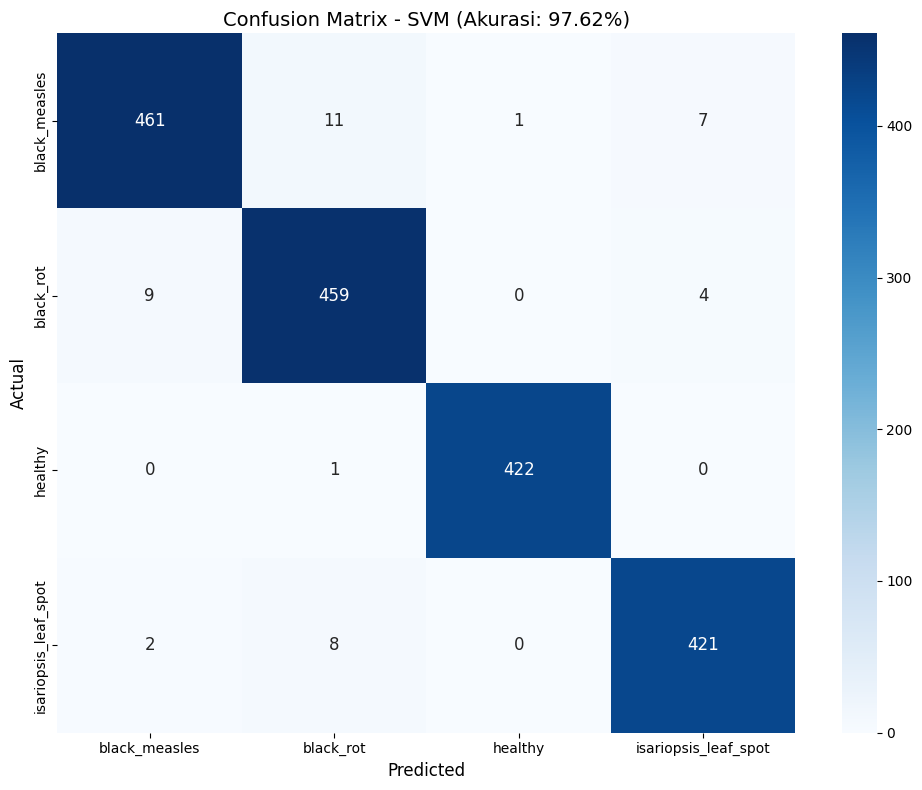


 ANALISIS PER KELAS:

 BLACK_MEASLES:
   ✅ Benar : 461/480 (96.0%)
   ❌ Salah : 19 data
 Diprediksi sebagai black_measles tapi bukan: 11 data

 BLACK_ROT:
   ✅ Benar : 459/472 (97.2%)
   ❌ Salah : 13 data
 Diprediksi sebagai black_rot tapi bukan: 20 data

 HEALTHY:
   ✅ Benar : 422/423 (99.8%)
   ❌ Salah : 1 data
 Diprediksi sebagai healthy tapi bukan: 1 data

 ISARIOPSIS_LEAF_SPOT:
   ✅ Benar : 421/431 (97.7%)
   ❌ Salah : 10 data
 Diprediksi sebagai isariopsis_leaf_spot tapi bukan: 11 data


In [30]:
# CONFUSION MATRIX AMAN

import os
from sklearn.metrics import confusion_matrix

os.makedirs('/content/drive/MyDrive/hasil', exist_ok=True)

try:
    y_test
    y_pred
except NameError:
    raise Exception("❌ Jalankan CELL (preprocessing) dan CELL (evaluasi) dulu!")

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            annot_kws={'size': 12})

plt.title(f'Confusion Matrix - SVM (Akurasi: {accuracy*100:.2f}%)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)

plt.tight_layout()

# SAVE AMAN
save_path = '/content/drive/MyDrive/hasil/confusion_matrix.png'
plt.savefig(save_path, dpi=150)

print(f"✅ Gambar berhasil disimpan di: {save_path}")

plt.show()

# ANALISIS PER KELAS
print("\n ANALISIS PER KELAS:")

for i, kelas in enumerate(le.classes_):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    total = cm[i, :].sum()

    print(f"\n {kelas.upper()}:")
    print(f"   ✅ Benar : {tp}/{total} ({tp/total*100:.1f}%)")
    print(f"   ❌ Salah : {fn} data")

    if fp > 0:
        print(f" Diprediksi sebagai {kelas} tapi bukan: {fp} data")

## **3. Roc Curve Analysis**

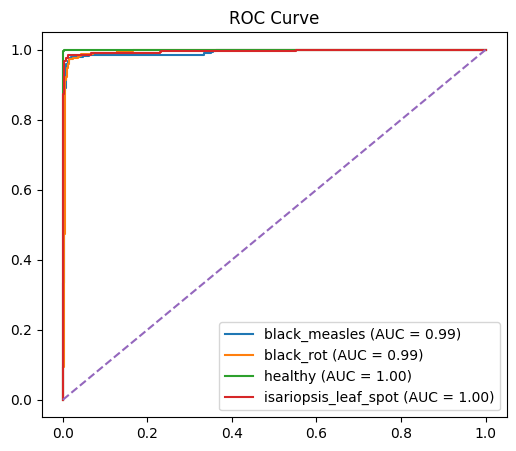

In [31]:
# ROC CURVE

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_score = best_model.decision_function(X_test_scaled)

plt.figure(figsize=(6,5))

for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.legend()
plt.show()

## **4. Feature Importance Analysis**

🎨 FEATURE IMPORTANCE (PERMUTATION)

📊 TOP 5 FITUR PALING BERPENGARUH:
   1. H_mean               : 22.82% ± 0.58%
   2. H_std                : 22.63% ± 0.22%
   3. homogeneity          : 22.34% ± 0.46%
   4. energy               : 22.17% ± 0.57%
   5. dissimilarity        : 21.72% ± 0.97%


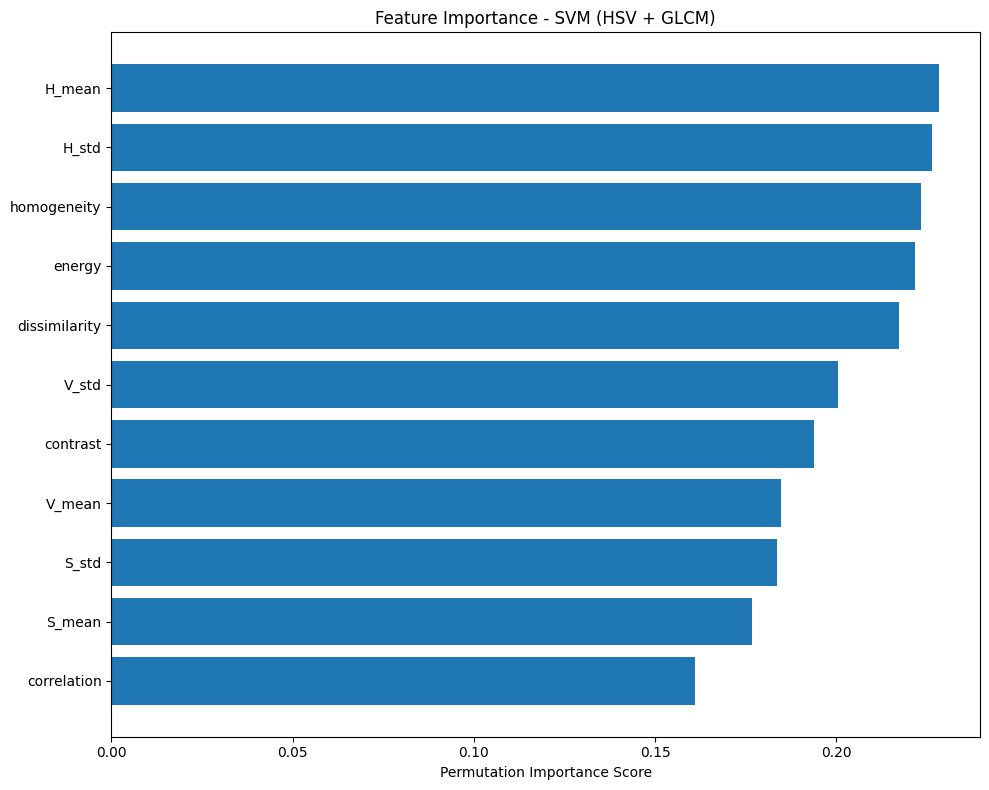

In [32]:
# FEATURE IMPORTANCE

print("="*60)
print("🎨 FEATURE IMPORTANCE (PERMUTATION)")
print("="*60)

from sklearn.inspection import permutation_importance

# Hitung permutation importance
perm_importance = permutation_importance(
    best_model, X_test_scaled, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

feature_names = X.columns.tolist()
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

print("\n📊 TOP 5 FITUR PALING BERPENGARUH:")
for i, idx in enumerate(sorted_idx[:5]):
    imp_mean = perm_importance.importances_mean[idx]
    imp_std = perm_importance.importances_std[idx]
    print(f"   {i+1}. {feature_names[idx]:20s} : {imp_mean*100:.2f}% ± {imp_std*100:.2f}%")

# Visualisasi
plt.figure(figsize=(10, 8))
plt.barh(range(len(feature_names)), perm_importance.importances_mean[sorted_idx])
plt.yticks(range(len(feature_names)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Permutation Importance Score')
plt.title('Feature Importance - SVM (HSV + GLCM)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hasil/feature_importance.png', dpi=150)
plt.show()

# **M. Model Interpretation**

In [33]:
print("\n🧠 INTERPRETASI MODEL")

print(f"""
Model SVM menghasilkan akurasi {accuracy*100:.2f}%.

Fitur paling penting:
1. {feature_names[sorted_idx[0]]}
2. {feature_names[sorted_idx[1]]}
3. {feature_names[sorted_idx[2]]}

Kesimpulan:
- HSV → mendeteksi perubahan warna daun
- GLCM → mendeteksi tekstur penyakit
- Kombinasi meningkatkan akurasi klasifikasi
""")


🧠 INTERPRETASI MODEL

Model SVM menghasilkan akurasi 97.62%.

Fitur paling penting:
1. H_mean
2. H_std
3. homogeneity

Kesimpulan:
- HSV → mendeteksi perubahan warna daun
- GLCM → mendeteksi tekstur penyakit
- Kombinasi meningkatkan akurasi klasifikasi



## **1. Save Model (SVM)**

In [34]:
# SAVE MODEL & HASIL
os.makedirs('/content/drive/MyDrive/hasil', exist_ok=True)

# Simpan model
joblib.dump(best_model, '/content/drive/MyDrive/hasil/svm_glcm.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/hasil/scaler.pkl')
joblib.dump(le, '/content/drive/MyDrive/hasil/label_encoder.pkl')

# Simpan dataset
df.to_csv('/content/drive/MyDrive/hasil/dataset.csv', index=False)

# Simpan hasil evaluasi
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV_Mean', 'CV_Std'],
    'Value': [accuracy, precision, recall, f1, cv_scores.mean(), cv_scores.std()]
})
results_df.to_csv('/content/drive/MyDrive/hasil/evaluation_results.csv', index=False)

print("✅ Semua file disimpan di /content/drive/MyDrive/hasil/")

✅ Semua file disimpan di /content/drive/MyDrive/hasil/
